In [5]:
!pip install plotly

# Bank Customer Churn Analysis

## Project Overview

Customer churn is one of the most important business challenges faced by banks. Acquiring new customers is significantly more expensive than retaining existing ones, making customer retention a key business objective. By identifying customers who are likely to leave, banks can proactively implement targeted retention strategies, improve customer satisfaction, and reduce financial losses.

In this project, we perform an end-to-end data analysis and machine learning workflow on a banking customer dataset. The project includes data cleaning, exploratory data analysis (EDA), feature engineering, predictive modeling, and business recommendations based on the findings.

---

## Business Problem

A retail bank wants to understand why customers are leaving the bank and identify the factors that contribute most to customer churn.

The objectives are:

- Analyze customer demographics and financial characteristics.
- Discover patterns associated with customer churn.
- Engineer useful features for predictive modeling.
- Build machine learning models capable of predicting whether a customer will leave the bank.
- Provide actionable business recommendations to reduce customer churn.

---

## Dataset

The dataset contains information for **10,000 bank customers** with demographic, financial, and account-related attributes.

Target Variable:

**Exited**

- 0 → Customer stayed with the bank
- 1 → Customer left the bank

---

## Tech Stack

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Plotly
- Scikit-Learn

---

## Project Workflow

1. Data Loading
2. Data Cleaning
3. Exploratory Data Analysis
4. Outlier Detection
5. Feature Engineering
6. Data Preprocessing
7. Machine Learning
8. Model Evaluation
9. Business Insights
10. Recommendations

In [7]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [10]:
## Data Loading
df = pd.read_csv("data/Bank Customer Churn Prediction.csv")

print("Dataset loaded successfully!\n")

print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Dataset loaded successfully!

Number of Rows    : 10000
Number of Columns : 12


In [15]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [16]:
df.tail()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,15628319,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [17]:
df.sample(5, random_state=42)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
6252,15687492,596,Germany,Male,32,3,96709.07,2,0,0,41788.37,0
4684,15736963,623,France,Male,43,1,0.00,2,1,1,146379.30,0
1731,15721730,601,Spain,Female,44,4,0.00,2,1,0,58561.31,0
4742,15762134,506,Germany,Male,59,8,119152.10,2,1,1,170679.74,0
4521,15648898,560,Spain,Female,27,7,124995.98,1,1,1,114669.79,0


## Initial Data Inspection
ll:

- Examine the dataset structure.
- Identify data types.
- Check for missing values.
- Detect duplicate records.
- Generate descriptive statistics.
- Make initial observations about the dataset.

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [27]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
credit_score,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
products_number,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
credit_card,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
active_member,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
estimated_salary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48
churn,10000.0,2.037000e-01,0.402769,0.00,0.00,0.000000e+00,0.000000e+00,1.00


In [28]:
df.describe(include="object").T

,count,unique,top,freq
country,10000,3,France,5014
gender,10000,2,Male,5457


In [29]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": (missing_values / len(df) * 100).round(2)
})

missing_df

,Missing Values,Percentage
customer_id,0,0.0
credit_score,0,0.0
country,0,0.0
gender,0,0.0
age,0,0.0
tenure,0,0.0
balance,0,0.0
products_number,0,0.0
credit_card,0,0.0
active_member,0,0.0


In [34]:
duplicates = df.duplicated().sum()
print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


In [31]:
df.columns.tolist()

['customer_id',
 'credit_score',
 'country',
 'gender',
 'age',
 'tenure',
 'balance',
 'products_number',
 'credit_card',
 'active_member',
 'estimated_salary',
 'churn']

# Exploratory Data Analysis (EDA)to:

- Understand the distribution of the target variable.
- Explore customer demographics.
- Analyze financial characteristics.
- Identify factors associated with customer churn.
- Generate business insights through visualizations.sis project.

In [33]:
# Churn Distribution

churn_counts = df["churn"].value_counts()
print(churn_counts)

churn
0    7963
1    2037
Name: count, dtype: int64


In [35]:
# Percentage distribution

(churn_counts / len(df) * 100).round(2)

churn
0    79.63
1    20.37
Name: count, dtype: float64

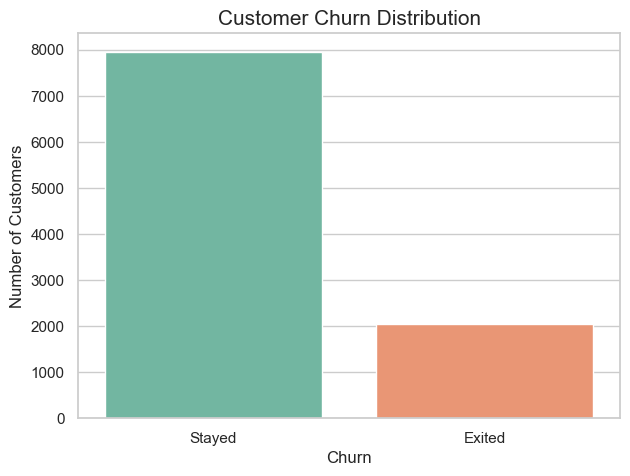

In [36]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="churn",
    palette="Set2"
)

plt.title("Customer Churn Distribution", fontsize=15)
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.xticks([0,1],["Stayed","Exited"])

plt.show()

### Observation

- The dataset is imbalanced.
- Most customers remained with the bank.
- A smaller proportion of customers exited.
- This class imbalance should be considered during model evaluation, where metrics such as Precision, Recall, and F1-score are more informative than Accuracy alone.

# 2. Customer Demographics Analysisze:

- Country distribution
- Gender distribution
- Age dist insights.

In [37]:
# Country Distribution

country_counts = df["country"].value_counts()

print(country_counts)

country
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64


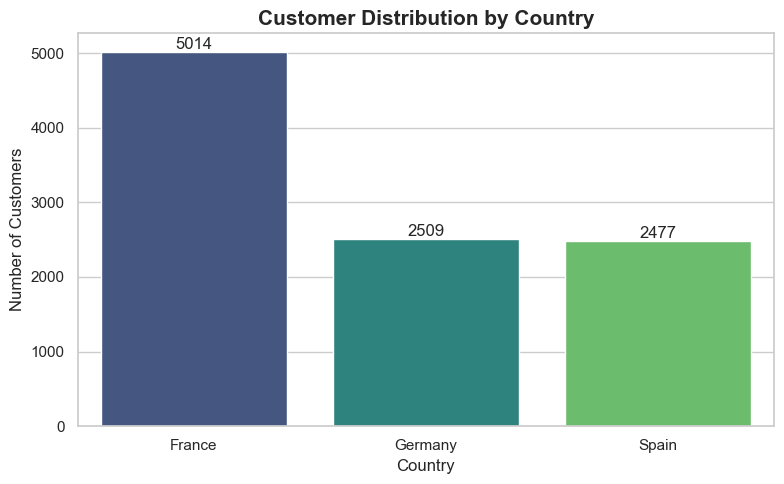

In [38]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="country",
    order=df["country"].value_counts().index,
    palette="viridis"
)

plt.title("Customer Distribution by Country", fontsize=15, weight="bold")
plt.xlabel("Country")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [41]:
## Country vs Customer Churn
country_churn = pd.crosstab(
    df["country"],
    df["churn"]
)

country_churn

churn,0,1
country,,
France,4204,810
Germany,1695,814
Spain,2064,413


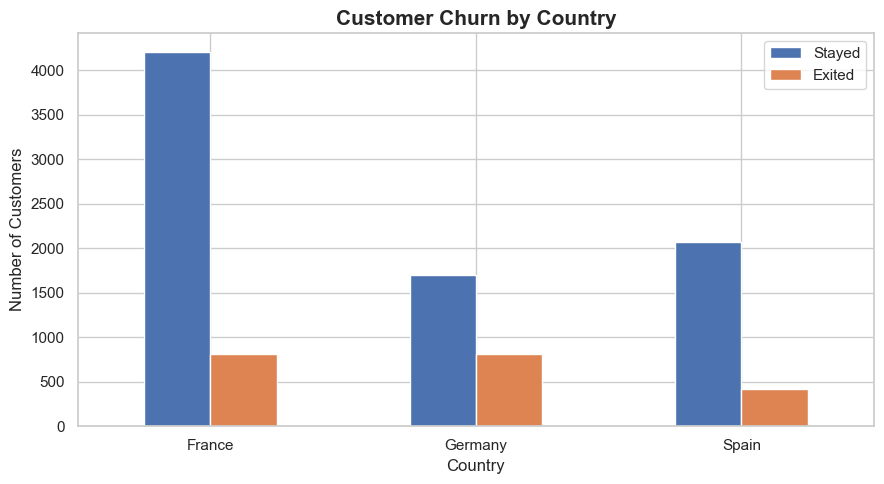

In [40]:
country_churn.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Customer Churn by Country", fontsize=15, weight="bold")
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.legend(["Stayed","Exited"])

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [42]:
country_churn_rate = (
    pd.crosstab(df["country"], df["churn"], normalize="index")
    *100
).round(2)

country_churn_rate

churn,0,1
country,,
France,83.85,16.15
Germany,67.56,32.44
Spain,83.33,16.67


### Key Findings

- France has the largest customer base, followed by Germany and Spain.
- Germany has the highest customer churn rate at **32.44%**, which is almost twice the churn rate observed in France (**16.15%**) and Spain (**16.67%**).
- Customers from France and Spain exhibit similar retention patterns, while German customers appear significantly more likely to leave the bank.

### Business Interpretation

The noticeably higher churn rate in Germany suggests that customers in this market may have lower satisfaction, stronger competition, or different financial behaviors compared to customers in France and Spain. The bank should prioritize customer retention initiatives in Germany by investigating region-specific factors contributing to customer attrition.

In [43]:
# Gender Distribution
gender_counts = df["gender"].value_counts()

gender_counts

gender
Male      5457
Female    4543
Name: count, dtype: int64

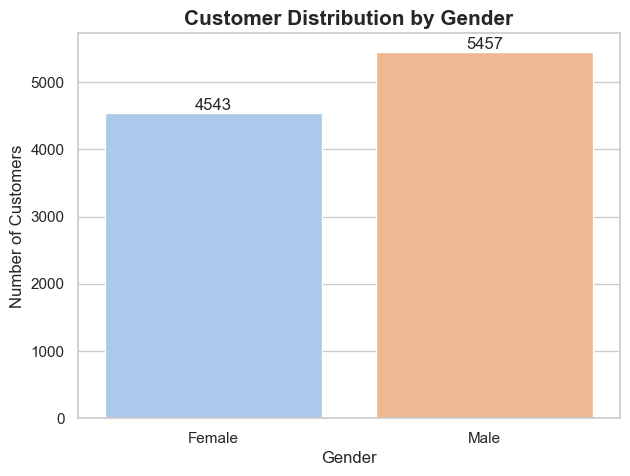

In [44]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="gender",
    palette="pastel"
)

plt.title("Customer Distribution by Gender",
          fontsize=15,
          weight="bold")

plt.xlabel("Gender")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [45]:
gender_churn = (
    pd.crosstab(df["gender"], df["churn"], normalize="index")
    *100
).round(2)

gender_churn

churn,0,1
gender,,
Female,74.93,25.07
Male,83.54,16.46


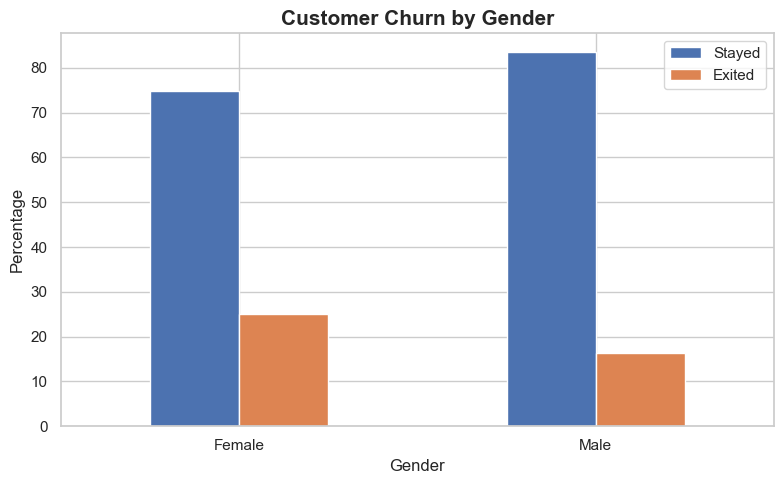

In [46]:
gender_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Customer Churn by Gender",
          fontsize=15,
          weight="bold")

plt.xlabel("Gender")
plt.ylabel("Percentage")

plt.legend(["Stayed","Exited"])

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

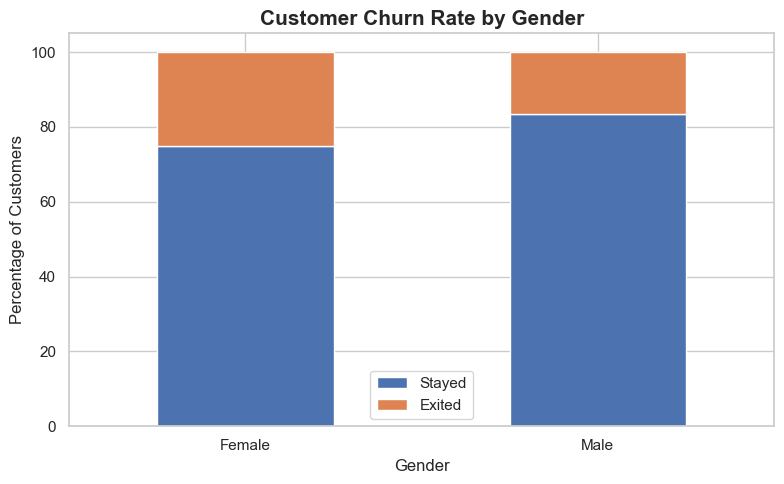

In [47]:
# Gender Churn Rate (%)

gender_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Customer Churn Rate by Gender", fontsize=15, weight="bold")
plt.xlabel("Gender")
plt.ylabel("Percentage of Customers")
plt.legend(["Stayed", "Exited"])

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Key Findings

- The customer base is relatively balanced between male and female customers.
- Female customers have a churn rate of **25.07%**, while male customers have a churn rate of **16.46%**.
- Female customers are noticeably more likely to leave the bank than male customers.

### Business Interpretation

The higher churn rate among female customers suggests that this customer segment may have different banking needs, expectations, or experiences. While the dataset does not explain the underlying causes, the bank should investigate factors such as product preferences, customer service experience, and engagement strategies to improve retention among female customers.

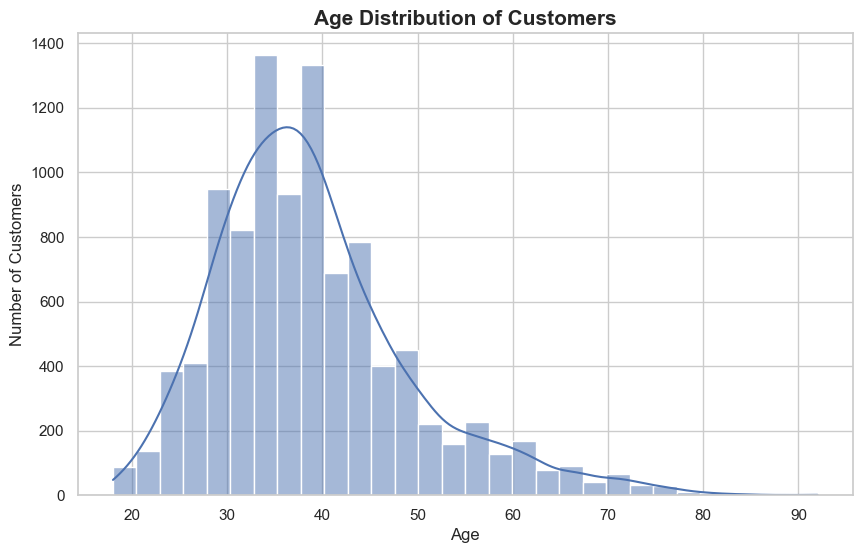

In [48]:
# Age Distribution

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="age",
    bins=30,
    kde=True
)

plt.title("Age Distribution of Customers",
          fontsize=15,
          weight="bold")

plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

### Key Findings

- The histogram shows how customer ages are distributed across the dataset.
- The density curve (KDE) highlights the overall trend in customer age.
- This visualization helps identify the most common age groups as well as any unusually young or old customers.

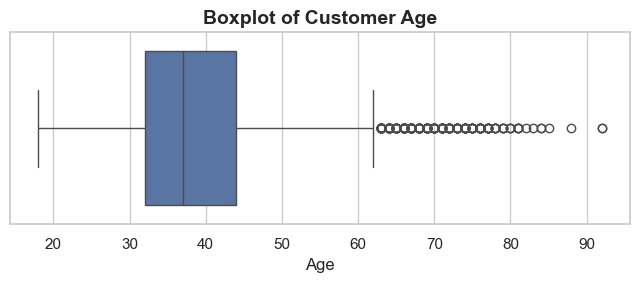

In [49]:
# Age Boxplot

plt.figure(figsize=(8,2.5))

sns.boxplot(
    data=df,
    x="age"
)

plt.title("Boxplot of Customer Age",
          fontsize=14,
          weight="bold")

plt.xlabel("Age")

plt.show()

### Key Findings

- The boxplot summarizes the spread of customer ages.
- Any points beyond the whiskers represent potential outliers.
- These values should be investigated before deciding whether they require treatment.

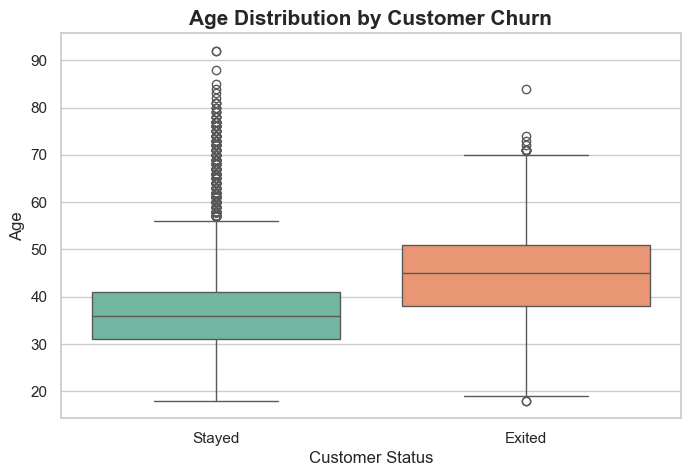

In [50]:
# Age vs Customer Churn

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="churn",
    y="age",
    palette="Set2"
)

plt.title("Age Distribution by Customer Churn",
          fontsize=15,
          weight="bold")

plt.xlabel("Customer Status")
plt.ylabel("Age")

plt.xticks([0,1],["Stayed","Exited"])

plt.show()

In [51]:
# Average Age by Customer Status

df.groupby("churn")["age"].agg(["mean","median","min","max"]).round(2)

,mean,median,min,max
churn,,,,
0,37.41,36.0,18,92
1,44.84,45.0,18,84


### Key Findings

- Customers who exited the bank have an average age of **44.84 years**, compared to **37.41 years** for customers who remained.
- The median age of customers who churned is **45 years**, while the median age of retained customers is **36 years**.
- This indicates that older customers are more likely to leave the bank than younger customers.

### Business Interpretation

The analysis suggests that age is an important factor associated with customer churn. Older customers may have different financial priorities, retirement planning needs, or access to competing banking products. The bank should consider designing targeted retention campaigns and personalized financial services for older customer segments to improve customer loyalty.

In [52]:
# Age Groups

age_bins = [18, 30, 40, 50, 60, 100]
age_labels = ["18-30", "31-40", "41-50", "51-60", "60+"]

df["age_group"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

In [53]:
age_group_churn = (
    pd.crosstab(
        df["age_group"],
        df["churn"],
        normalize="index"
    ) * 100
).round(2)

age_group_churn

churn,0,1
age_group,,
18-30,92.48,7.52
31-40,87.91,12.09
41-50,66.03,33.97
51-60,43.79,56.21
60+,75.22,24.78


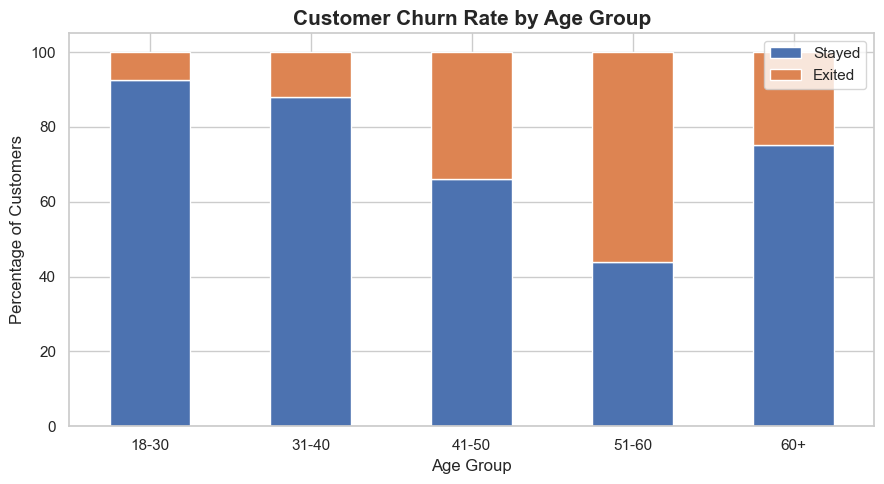

In [54]:
age_group_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(9,5)
)

plt.title("Customer Churn Rate by Age Group",
          fontsize=15,
          weight="bold")

plt.xlabel("Age Group")
plt.ylabel("Percentage of Customers")

plt.legend(["Stayed", "Exited"])

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# 3. Financial Analysisze:

- Credit Score
- Account Balance
- Estimatetrategies.

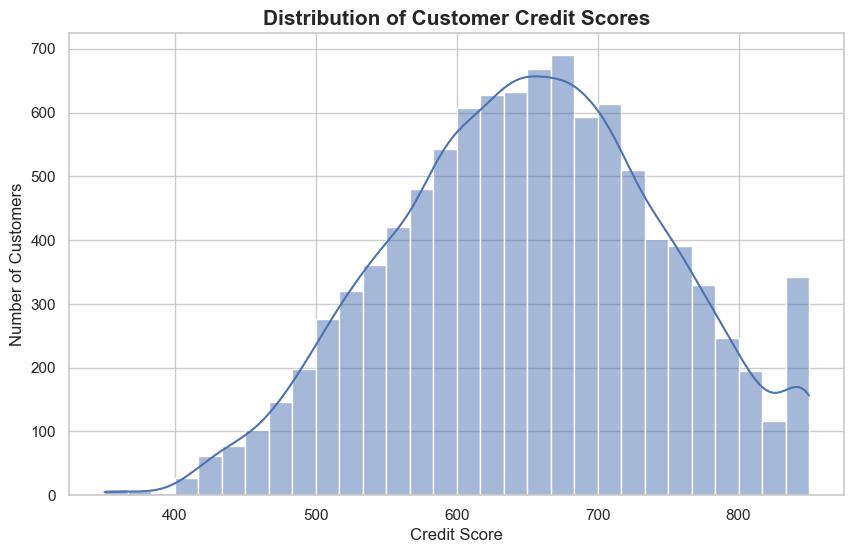

In [55]:
# Credit Score Distribution

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="credit_score",
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Credit Scores",
          fontsize=15,
          weight="bold")

plt.xlabel("Credit Score")
plt.ylabel("Number of Customers")

plt.show()

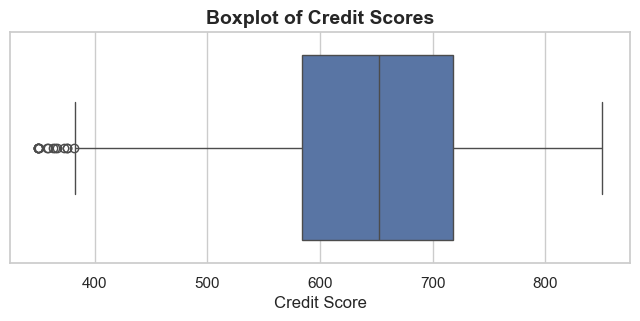

In [56]:
plt.figure(figsize=(8,3))

sns.boxplot(
    data=df,
    x="credit_score"
)

plt.title("Boxplot of Credit Scores",
          fontsize=14,
          weight="bold")

plt.xlabel("Credit Score")

plt.show()

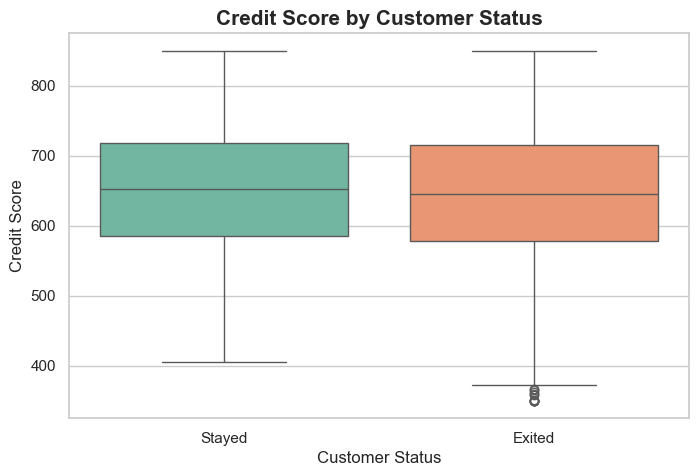

In [57]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="churn",
    y="credit_score",
    palette="Set2"
)

plt.title("Credit Score by Customer Status",
          fontsize=15,
          weight="bold")

plt.xlabel("Customer Status")
plt.ylabel("Credit Score")

plt.xticks([0,1],["Stayed","Exited"])

plt.show()

In [58]:
df.groupby("churn")["credit_score"].agg(
    ["mean","median","min","max"]
).round(2)

,mean,median,min,max
churn,,,,
0,651.85,653.0,405,850
1,645.35,646.0,350,850


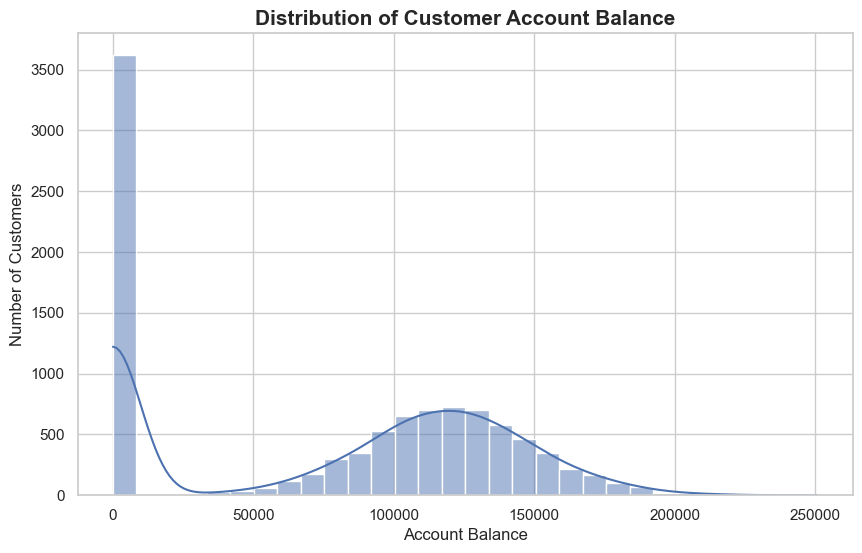

In [59]:
# Balance Distribution

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="balance",
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Account Balance",
          fontsize=15,
          weight="bold")

plt.xlabel("Account Balance")
plt.ylabel("Number of Customers")

plt.show()

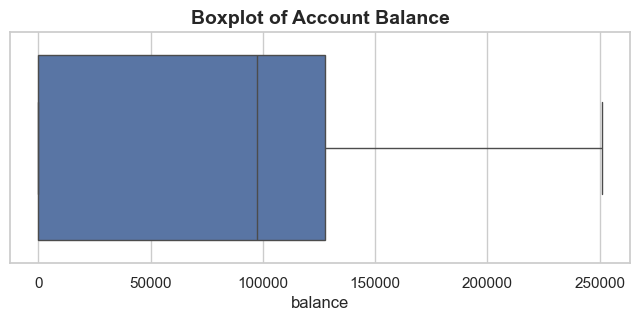

In [60]:
plt.figure(figsize=(8,3))

sns.boxplot(
    data=df,
    x="balance"
)

plt.title("Boxplot of Account Balance",
          fontsize=14,
          weight="bold")

plt.show()

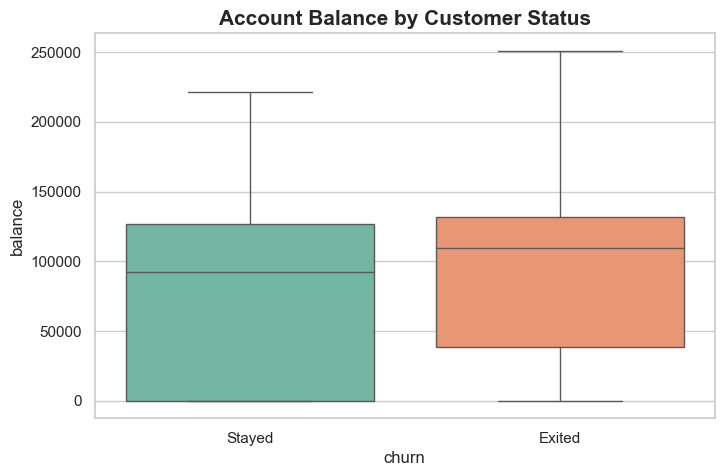

In [61]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="churn",
    y="balance",
    palette="Set2"
)

plt.title("Account Balance by Customer Status",
          fontsize=15,
          weight="bold")

plt.xticks([0,1],["Stayed","Exited"])

plt.show()

In [62]:
df.groupby("churn")["balance"].agg(
    ["mean","median","min","max"]
).round(2)

,mean,median,min,max
churn,,,,
0,72745.30,92072.68,0.0,221532.80
1,91108.54,109349.29,0.0,250898.09


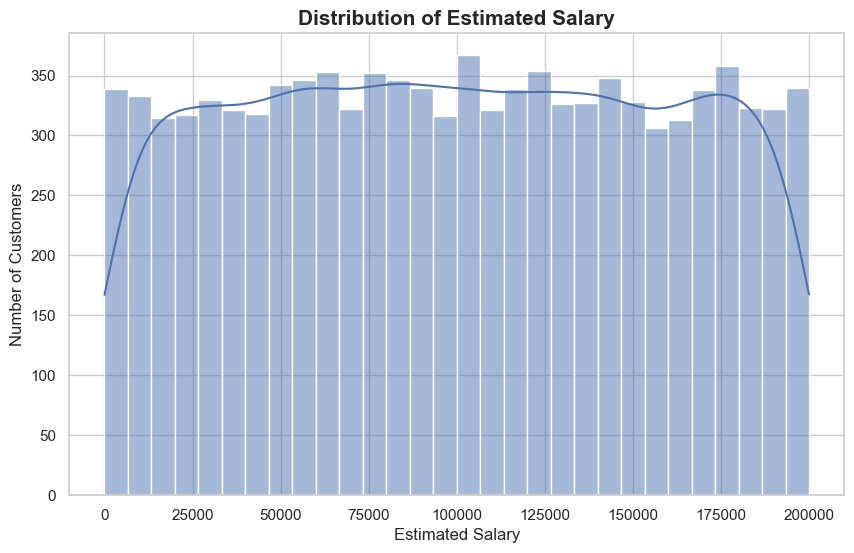

In [63]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="estimated_salary",
    bins=30,
    kde=True
)

plt.title("Distribution of Estimated Salary",
          fontsize=15,
          weight="bold")

plt.xlabel("Estimated Salary")
plt.ylabel("Number of Customers")

plt.show()

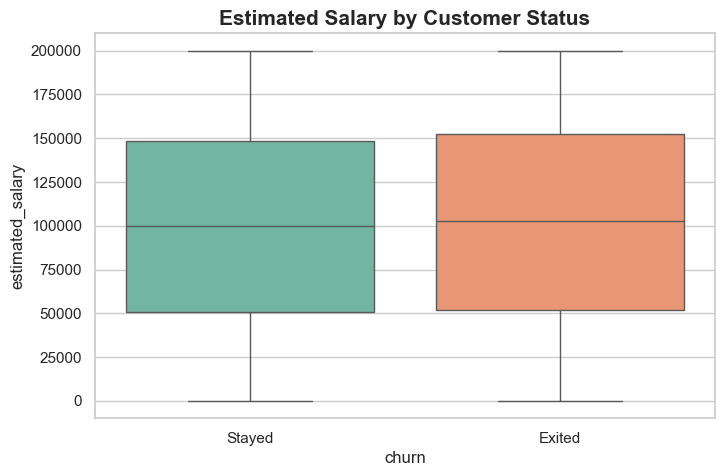

In [64]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="churn",
    y="estimated_salary",
    palette="Set2"
)

plt.title("Estimated Salary by Customer Status",
          fontsize=15,
          weight="bold")

plt.xticks([0,1],["Stayed","Exited"])

plt.show()

In [65]:
df.groupby("churn")["estimated_salary"].agg(
    ["mean","median","min","max"]
).round(2)

,mean,median,min,max
churn,,,,
0,99738.39,99645.04,90.07,199992.48
1,101465.68,102460.84,11.58,199808.10


In [67]:
# Correlation Analysis

corr = df.corr(numeric_only=True)

corr

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
customer_id,1.000000,0.005308,0.009497,-0.014883,-0.012419,0.016972,-0.014025,0.001665,0.015271,-0.006248
credit_score,0.005308,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
age,0.009497,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
tenure,-0.014883,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
balance,-0.012419,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
products_number,0.016972,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
credit_card,-0.014025,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
active_member,0.001665,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
estimated_salary,0.015271,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097
churn,-0.006248,-0.027094,0.285323,-0.014001,0.118533,-0.047820,-0.007138,-0.156128,0.012097,1.000000


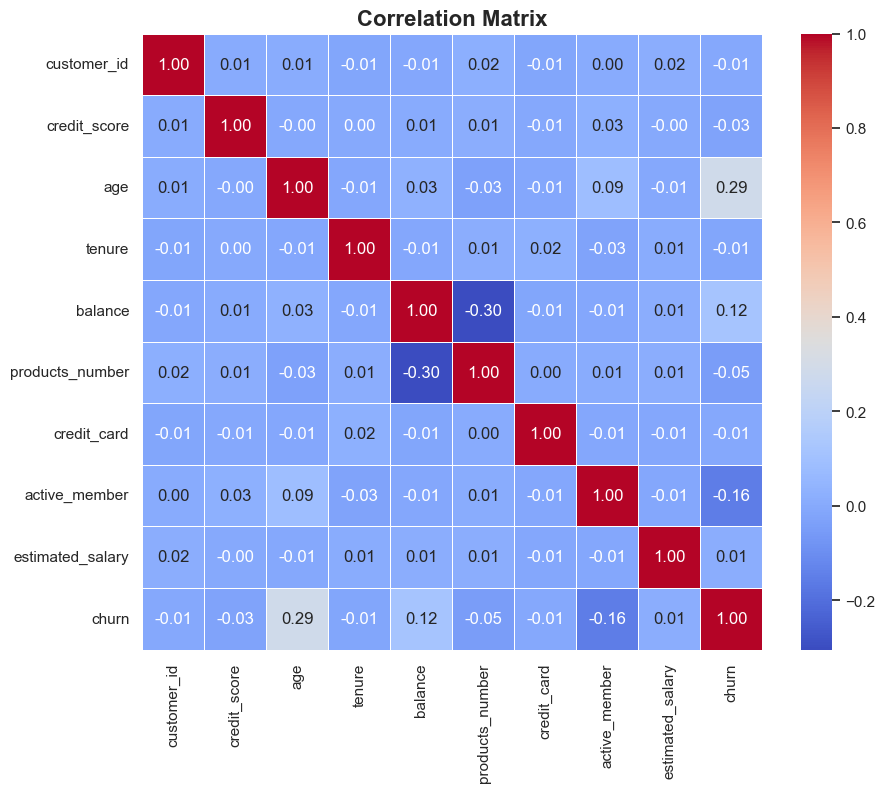

In [68]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix",
          fontsize=16,
          weight="bold")

plt.show()

# 4. Feature Engineering & Data Preprocessing

- Removing irrelevant features
- Encoding categorical variables
- Separating features and target variable
- Splitting the dataset into training and testing sets
- Feature scaling (for Logistic Regression)

In [69]:
# Remove Customer ID

df = df.drop(columns=["customer_id"])

df.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,age_group
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,41-50
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,41-50
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,41-50
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,31-40
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,41-50


In [82]:
# Features and Target

df = df.drop(columns=["age_group"])

X = df.drop("churn", axis=1)

y = df["churn"]

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (10000, 10)
Target Shape  : (10000,)


In [83]:
# Numerical & Categorical Columns
categorical_features = X.select_dtypes(include="object").columns.tolist()

numerical_features = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical Features")
print(categorical_features)

print()

print("Numerical Features")
print(numerical_features)

Categorical Features
['country', 'gender']

Numerical Features
['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary']


In [84]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (8000, 10)
Testing Set  : (2000, 10)


In [85]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
# Preprocessing Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [86]:
# Apply One-Hot Encoding

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(8000, 11)
(2000, 11)


In [87]:
from sklearn.preprocessing import StandardScaler
# Standard Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_processed)

X_test_scaled = scaler.transform(X_test_processed)

In [88]:
# Train Logistic Regression Model

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [89]:
# Predictions

y_pred_log = log_model.predict(X_test_scaled)

y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

In [90]:
from sklearn.metrics import accuracy_score

log_accuracy = accuracy_score(y_test, y_pred_log)

print(f"Accuracy : {log_accuracy:.4f}")

Accuracy : 0.8080


## Model Evaluation

The Logistic Regression model achieved an **accuracy of 80.80%** on the test dataset.

While overall accuracy is reasonably high, accuracy alone does not provide a complete picture because the dataset contains more customers who stayed than customers who churned. Therefore, additional metrics such as precision, recall, F1-score, and ROC-AUC are used to evaluate the model's ability to identify churned customers.

In [91]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



### Classification Report

#### Key Findings

- Overall model accuracy is **80.80%**.
- The model performs well in identifying customers who remain with the bank, achieving a recall of **97%** for the non-churn class.
- For churned customers, the model achieves a precision of **59%**, meaning that when it predicts churn, the prediction is correct more than half the time.
- However, the recall for churned customers is only **19%**, indicating that many customers who actually churn are not identified by the model.

#### Business Interpretation

Although Logistic Regression provides a useful baseline, it is relatively conservative when predicting customer churn. As a result, many at-risk customers are classified as retained customers.

For a customer retention strategy, missing potential churners can reduce the effectiveness of intervention campaigns. Therefore, more flexible models such as Random Forest are expected to improve churn detection.

In [92]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_log)

cm

array([[1540,   53],
       [ 331,   76]], dtype=int64)

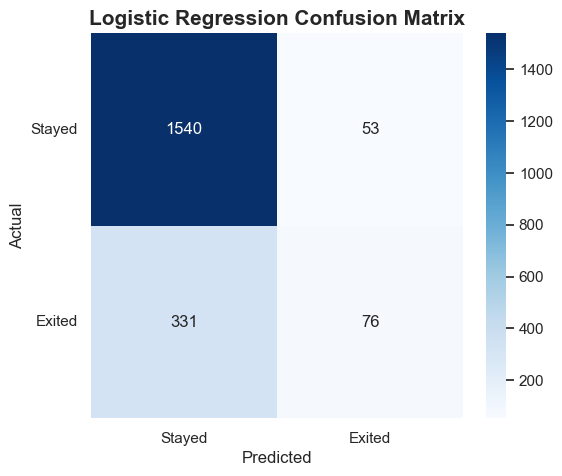

In [93]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix",
          fontsize=15,
          weight="bold")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.xticks([0.5, 1.5], ["Stayed", "Exited"])
plt.yticks([0.5, 1.5], ["Stayed", "Exited"], rotation=0)

plt.show()

In [94]:
from sklearn.metrics import roc_auc_score

log_auc = roc_auc_score(y_test, y_prob_log)

print(f"ROC AUC Score : {log_auc:.4f}")

ROC AUC Score : 0.7748


### ROC-AUC Score

The Logistic Regression model achieved a **ROC-AUC score of 0.7748**.

This indicates that the model has a reasonable ability to distinguish between customers who are likely to churn and those who are likely to remain. While the performance is acceptable for a baseline model, there is room for improvement using more complex machine learning algorithms.

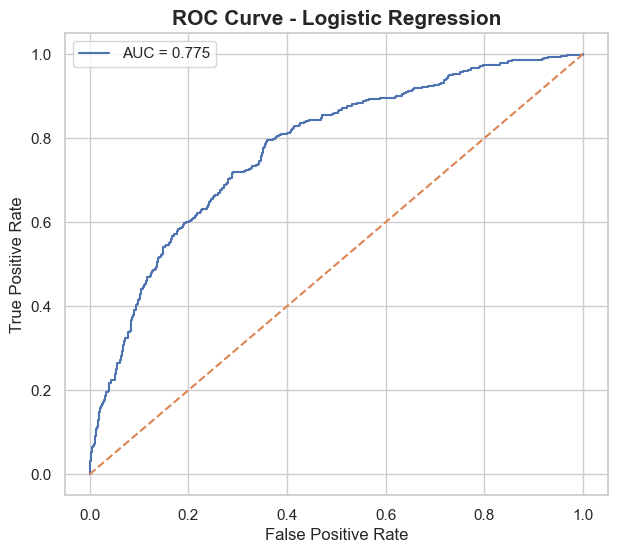

In [95]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob_log)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label=f"AUC = {log_auc:.3f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression",
          fontsize=15,
          weight="bold")

plt.legend()

plt.show()

In [96]:
feature_names = preprocessor.get_feature_names_out()

coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": log_model.coef_[0]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

coefficients.head(10)

,Feature,Coefficient
4,remainder__age,0.738847
9,remainder__active_member,-0.515485
0,cat__country_Germany,0.356679
2,cat__gender_Male,-0.260851
6,remainder__balance,0.160622
3,remainder__credit_score,-0.085986
7,remainder__products_number,-0.070292
10,remainder__estimated_salary,0.047725
8,remainder__credit_card,-0.032208
5,remainder__tenure,-0.020071


### Logistic Regression Coefficients

The magnitude of the model coefficients provides insight into which variables have the strongest influence on churn prediction.

#### Most Influential Features

- **Age** has the strongest positive relationship with customer churn.
- **Active Member** has a strong negative coefficient, indicating that active customers are less likely to churn.
- Customers from **Germany** are more likely to churn than those from the reference country.
- **Male** customers are less likely to churn than female customers, which aligns with the exploratory data analysis.
- Higher **Account Balance** is associated with an increased likelihood of churn.
- Higher **Credit Score** is associated with a slightly lower likelihood of churn.

These findings are consistent with the exploratory data analysis and suggest that customer demographics, engagement, and financial behavior all contribute to churn prediction.

In [97]:
# Logistic Regression Performance Summary

log_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "ROC-AUC",
        "Precision (Churn)",
        "Recall (Churn)",
        "F1-Score (Churn)"
    ],
    "Value": [
        round(log_accuracy, 4),
        round(log_auc, 4),
        0.59,
        0.19,
        0.28
    ]
})

log_results

,Metric,Value
0,Accuracy,0.8080
1,ROC-AUC,0.7748
2,Precision (Churn),0.5900
3,Recall (Churn),0.1900
4,F1-Score (Churn),0.2800


In [98]:
# Train Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_processed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [99]:
# Predictions

y_pred_rf = rf_model.predict(X_test_processed)

y_prob_rf = rf_model.predict_proba(X_test_processed)[:,1]

In [100]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Accuracy : {rf_accuracy:.4f}")

Accuracy : 0.8660


In [101]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.47      0.59       407

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000



In [102]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

cm_rf

array([[1542,   51],
       [ 217,  190]], dtype=int64)

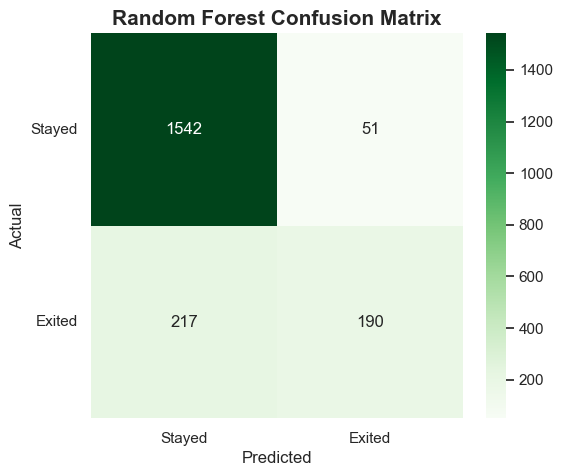

In [103]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title(
    "Random Forest Confusion Matrix",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.xticks([0.5,1.5],["Stayed","Exited"])
plt.yticks([0.5,1.5],["Stayed","Exited"],rotation=0)

plt.show()

In [104]:
from sklearn.metrics import roc_auc_score

rf_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

print(f"ROC AUC : {rf_auc:.4f}")

ROC AUC : 0.8554


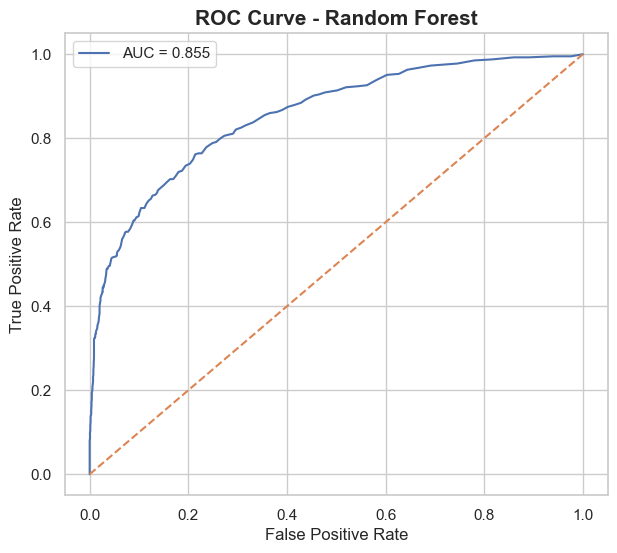

In [105]:
from sklearn.metrics import roc_curve

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"AUC = {rf_auc:.3f}"
)

plt.plot([0,1],[0,1],"--")

plt.title(
    "ROC Curve - Random Forest",
    fontsize=15,
    weight="bold"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

In [106]:
feature_importance = pd.DataFrame({
    "Feature": preprocessor.get_feature_names_out(),
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
4,remainder__age,0.237494
10,remainder__estimated_salary,0.146226
3,remainder__credit_score,0.143223
6,remainder__balance,0.143221
7,remainder__products_number,0.129225
5,remainder__tenure,0.080530
9,remainder__active_member,0.040699
0,cat__country_Germany,0.028415
8,remainder__credit_card,0.018837
2,cat__gender_Male,0.017826


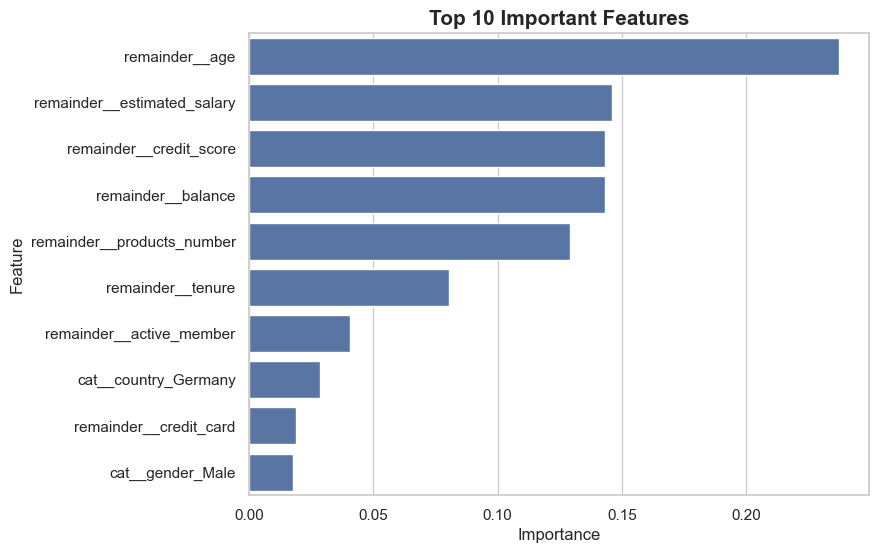

In [107]:
top10 = feature_importance.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Important Features",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [109]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "ROC-AUC",
        "Precision (Churn)",
        "Recall (Churn)",
        "F1-Score (Churn)"
    ],
    "Logistic Regression": [
        round(log_accuracy, 4),
        round(log_auc, 4),
        0.59,
        0.19,
        0.28
    ],
    "Random Forest": [
        round(rf_accuracy, 4),
        round(rf_auc, 4),
        0.79,
        0.47,
        0.59
    ]
})

comparison

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.8080,0.8660
1,ROC-AUC,0.7748,0.8554
2,Precision (Churn),0.5900,0.7900
3,Recall (Churn),0.1900,0.4700
4,F1-Score (Churn),0.2800,0.5900


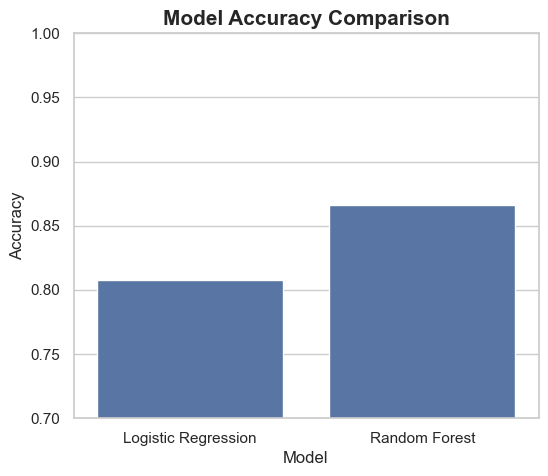

In [110]:
accuracy_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [log_accuracy, rf_accuracy]
})

plt.figure(figsize=(6,5))

sns.barplot(
    data=accuracy_df,
    x="Model",
    y="Accuracy"
)

plt.title(
    "Model Accuracy Comparison",
    fontsize=15,
    weight="bold"
)

plt.ylim(0.70, 1.0)

plt.show()

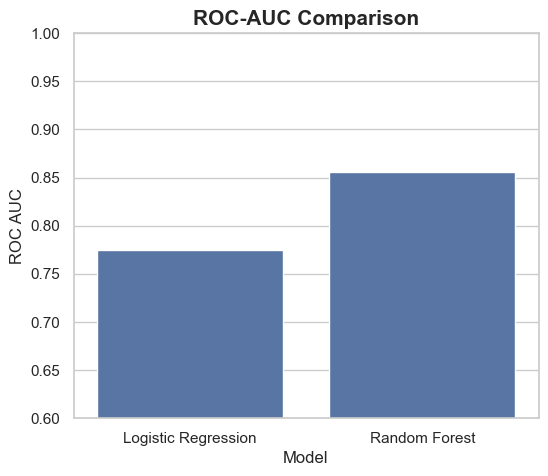

In [111]:
auc_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "ROC AUC": [log_auc, rf_auc]
})

plt.figure(figsize=(6,5))

sns.barplot(
    data=auc_df,
    x="Model",
    y="ROC AUC"
)

plt.title(
    "ROC-AUC Comparison",
    fontsize=15,
    weight="bold"
)

plt.ylim(0.60, 1.0)

plt.show()

# 9. Conclusion

This project analyzed customer churn using demographic, financial, and behavioral information from a retail bank.

Exploratory Data Analysis revealed several important trends:

- Germany exhibited the highest churn rate.
- Older customers were more likely to leave the bank.
- Active membership significantly reduced churn probability.
- Account balance and customer engagement influenced retention.

Two machine learning models were evaluated.

Logistic Regression provided a strong baseline with good interpretability, while Random Forest demonstrated superior predictive performance by achieving higher precision, recall, and overall accuracy for churn prediction.

Overall, Random Forest was selected as the preferred model because of its improved ability to identify customers at risk of leer relationships.